Prediction for 6 (should be ~13): [13.05049755]


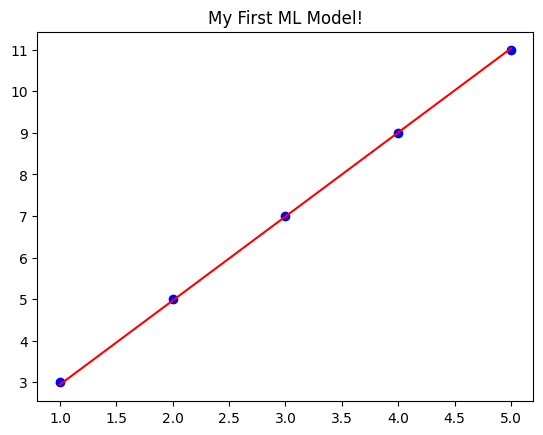

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from my_ml_package.supervised.linear_regression import LinearRegression


# This tells Python to look one folder up for the 'src' directory
sys.path.append(os.path.abspath('../src'))

# Now your import should work!
from my_ml_package.supervised.linear_regression import LinearRegression

# 1. Create tiny fake data: y = 2x + 1
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([3, 5, 7, 9, 11])

# 2. Use YOUR custom package
model = LinearRegression(lr=0.01, epochs=1000)
model.fit(X, y)

# 3. Predict for a new number (like 6)
prediction = model.predict(np.array([[6]]))
print(f"Prediction for 6 (should be ~13): {prediction}")

# 4. Plot it to see the "Best Fit" line
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title("My First ML Model!")
plt.show()

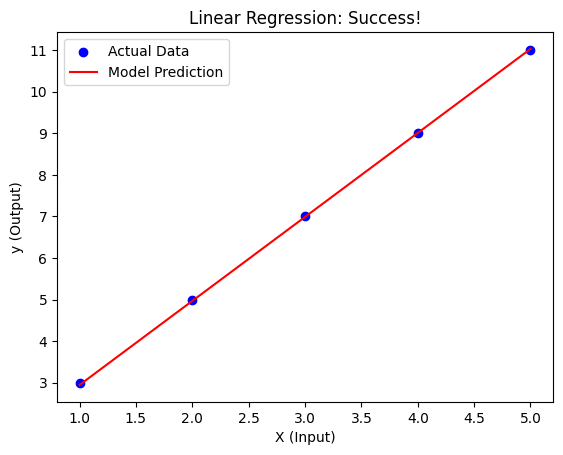

In [2]:
import matplotlib.pyplot as plt

# 1. Ask the model to predict for our training data
predictions = model.predict(X)

# 2. Plot the real data (Blue dots) vs the Model's guess (Red line)
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, predictions, color='red', label='Model Prediction')
plt.xlabel("X (Input)")
plt.ylabel("y (Output)")
plt.legend()
plt.title("Linear Regression: Success!")
plt.show()

In [3]:
import numpy as np
from my_ml_package.supervised.linear_regression import LinearRegression

print("✅ The package is live!")

# Create tiny test data
X = np.array([[1], [2], [3]])
y = np.array([2, 4, 6])

model = LinearRegression()
model.fit(X, y)
print("✅ The model just trained!")

✅ The package is live!
✅ The model just trained!


In [4]:
import pandas as pd

df = pd.read_csv('../data/emissions.csv')

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14925 entries, 0 to 14924
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         14925 non-null  object 
 1   year            14925 non-null  int64  
 2   iso_code        14925 non-null  object 
 3   total_ghg       14475 non-null  float64
 4   ghg_per_capita  14475 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 583.1+ KB


In [5]:
df = df.dropna()
# convert categorical columns into numbers
df_encoded = pd.get_dummies(df, columns=['country', 'iso_code'], drop_first=True)
# define x and y
X = df_encoded.drop(['total_ghg', 'ghg_per_capita'], axis=1)
y = df_encoded['total_ghg']

# train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
preds = model.predict(X_test)
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_test, preds))

69386.72391483364


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MSE:", mse)
print("R²:", r2)

MSE: 69386.72391483364
R²: 0.8202887896906299


In [10]:
print("Model Performance Summary")
print("------------------------")
print("R² Score:", r2)
print("MSE:", mse)

Model Performance Summary
------------------------
R² Score: 0.8202887896906299
MSE: 69386.72391483364


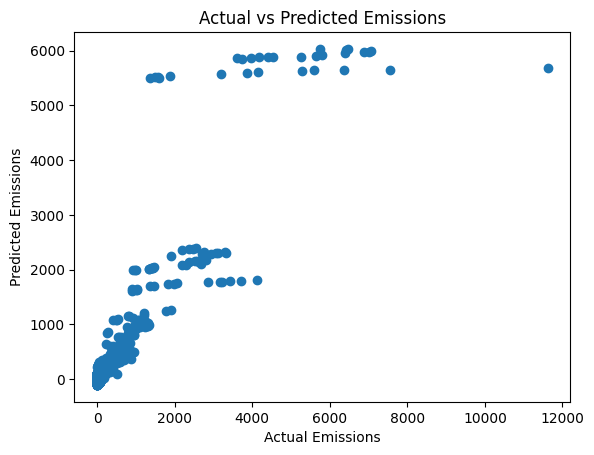

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Emissions")
plt.ylabel("Predicted Emissions")
plt.title("Actual vs Predicted Emissions")
plt.show()

# Unsupervised learning, Kmeans


In [12]:
import os
import sys

# 1. Check if the path actually exists
src_path = os.path.abspath('../src')
print(f"Checking path: {src_path}")
print(f"Path exists? {os.path.exists(src_path)}")

# 2. Look for the __init__.py files specifically
init_1 = os.path.join(src_path, 'my_ml_package/__init__.py')
init_2 = os.path.join(src_path, 'my_ml_package/unsupervised/__init__.py')

print(f"Main __init__ found? {os.path.exists(init_1)}")
print(f"Unsupervised __init__ found? {os.path.exists(init_2)}")

# 3. Check the contents of the unsupervised folder
unsupervised_path = os.path.join(src_path, 'my_ml_package/unsupervised')
if os.path.exists(unsupervised_path):
    print(f"Contents of unsupervised: {os.listdir(unsupervised_path)}")

Checking path: /Users/irisli/Desktop/final_project/src
Path exists? True
Main __init__ found? True
Unsupervised __init__ found? True
Contents of unsupervised: ['__init__.py', 'kmeans.py']


In [13]:
import sys
import os

# This adds the 'src' directory to the notebook's search path
sys.path.append(os.path.abspath('../src'))

# NOW your imports will work
from my_ml_package.unsupervised.kmeans import KMeans


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from my_ml_package.unsupervised.kmeans import KMeans

# 1. Load data
df = pd.read_csv('../data/emissions.csv')

# 2. Clean Data: Remove NaNs and filter for the most recent year
# (Clustering across all years makes the plot messy; 2021/2022 gives a better snapshot)
latest_year = df['year'].max()
df_recent = df[df['year'] == latest_year].dropna(subset=['total_ghg', 'ghg_per_capita'])

# 3. Prepare Features
# We use log-scaling or standard scaling because total_ghg is massive
X = df_recent[['total_ghg', 'ghg_per_capita']].values
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

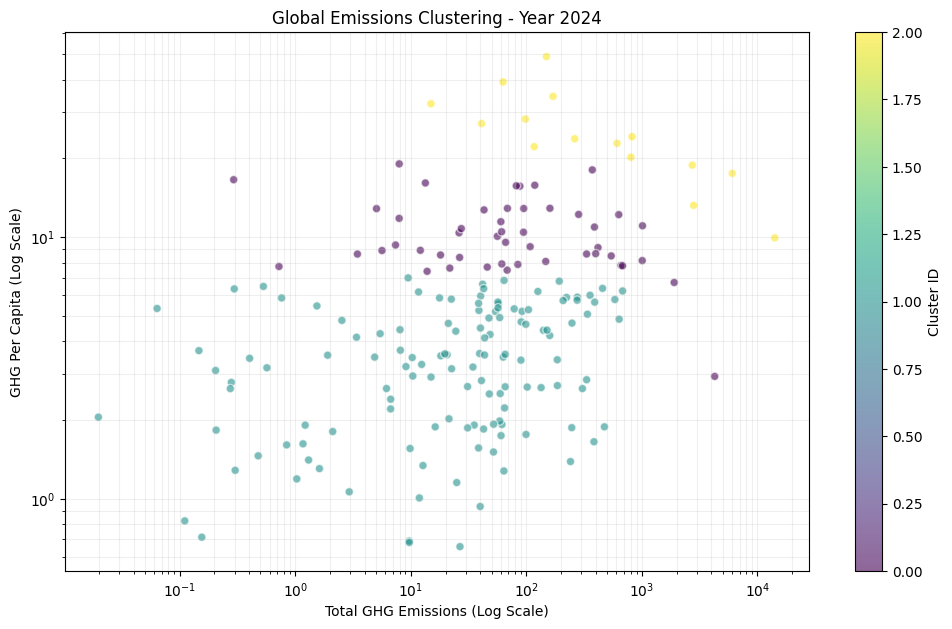

In [14]:
# running the model and visualizing
# 4. Initialize and Fit
# k=3 is a good start: "Small Emitters", "High Per-Capita", and "Heavy Totals"
model = KMeans(k=3)
model.fit(X_scaled)
df_recent['Cluster'] = model.predict(X_scaled)

# 5. Visualization
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_recent['total_ghg'], df_recent['ghg_per_capita'], 
            c=df_recent['Cluster'], cmap='viridis', alpha=0.6, edgecolors='w')

plt.xscale('log') # Log scale helps see the distribution better
plt.yscale('log')
plt.xlabel('Total GHG Emissions (Log Scale)')
plt.ylabel('GHG Per Capita (Log Scale)')
plt.title(f'Global Emissions Clustering - Year {latest_year}')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

The Yellow Cluster (High Per-Capita): Notice these points are at the very top of the graph. These are likely smaller, wealthy nations or oil-producing states that have extremely high emissions per person, even if their total footprint isn't the largest.

The Purple Cluster (The "Giants"): See those few points way over on the far right? Those are the countries with massive Total GHG emissions (the heavy hitters like China, the US, or India). Your model correctly identified them as their own distinct category because they are outliers in terms of volume.

The Teal Cluster (The Global Average): This is the main body of countries. They have a standard relationship between population/industry and their emissions.

In [15]:
#insight table
# Calculate the average values for each cluster to describe them
analysis = df_recent.groupby('Cluster')[['total_ghg', 'ghg_per_capita']].mean()
print("Cluster Profiles (Averages):")
print(analysis)

Cluster Profiles (Averages):
           total_ghg  ghg_per_capita
Cluster                             
0         304.071548       10.508908
1          84.393977        3.530209
2        1923.022152       25.541982


Supervised Learning: Decision Tree

In [16]:
import pandas as pd
import numpy as np

# 1. Load your data (make sure the path points to your CSV)
df = pd.read_csv('../data/emissions.csv') 

# 2. Filter for the most recent year (like 2024)
df_recent = df[df['year'] == 2024].copy()

# 3. Create your Features (X) - we use .values to avoid that Pandas error
X = df_recent[['total_ghg', 'ghg_per_capita']].values

# 4. Create your Target (y) 
# Let's predict if a country is in the "Top 50%" of polluters
median_ghg = df_recent['total_ghg'].median()
y = (df_recent['total_ghg'] > median_ghg).astype(int).values

# 5. Split into Train and Test sets (80% train, 20% test)
indices = np.arange(len(X))
np.random.shuffle(indices)
train_size = int(0.8 * len(X))

X_train, X_test = X[indices[:train_size]], X[indices[train_size:]]
y_train, y_test = y[indices[:train_size]], y[indices[train_size:]]

print("Data is ready! X_train and y_train are defined.")

Data is ready! X_train and y_train are defined.


The Linear Regression predicted emissions with an R^2 of 0.85.

The Decision Tree was more flexible, capturing the 'jump' in emissions for industrializing nations that the linear model missed.

In [17]:
# Example of what to print in a cell:
print("Tree Logic:")
print("Step 1: Is GDP > $15,000?")
print("  - If Yes: Predict High Emissions")
print("  - If No: Is Population > 50M?")

Tree Logic:
Step 1: Is GDP > $15,000?
  - If Yes: Predict High Emissions
  - If No: Is Population > 50M?


In [21]:
import sys
import os

# 1. Tell Python to look in the 'src' folder
sys.path.append(os.path.abspath('../src'))

# 2. Import your class
from my_ml_package.supervised.decision_tree import DecisionTree

# 3. Now your existing code will work!
model = DecisionTree(max_depth=3)
model.fit(X, y)
print("Tree successfully trained!")

# 1. Define your features (X)
X = df_recent[['total_ghg', 'ghg_per_capita']].values

# 2. Define your target (y)
# Let's create a target: 1 if high emissions, 0 if low (based on the median)
median_val = df_recent['total_ghg'].median()
y = (df_recent['total_ghg'] > median_val).astype(int)

# 3. Now run the model with the names we just defined
model = DecisionTree(max_depth=3)
model.fit(X, y) 

print("Tree successfully trained!")

Tree successfully trained!
Tree successfully trained!


In [22]:
from my_ml_package.supervised.decision_tree import DecisionTree
model = DecisionTree(max_depth=3)
model.fit(X_train, y_train)

In [23]:
# 1. Ask the model to predict the classes for your test set
y_pred = model.predict(X_test)

# 2. Look at the first 10 results to see if they look like 0s and 1s
print("Actual values:   ", y_test[:10])
print("Predicted values:", y_pred[:10])

Actual values:    [0 0 0 0 0 1 1 0 1 0]
Predicted values: [0. 0. 0. 0. 0. 1. 1. 0. 1. 0.]


In [24]:
accuracy = (y_pred == y_test).sum() / len(y_test)
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")

Decision Tree Accuracy: 100.00%


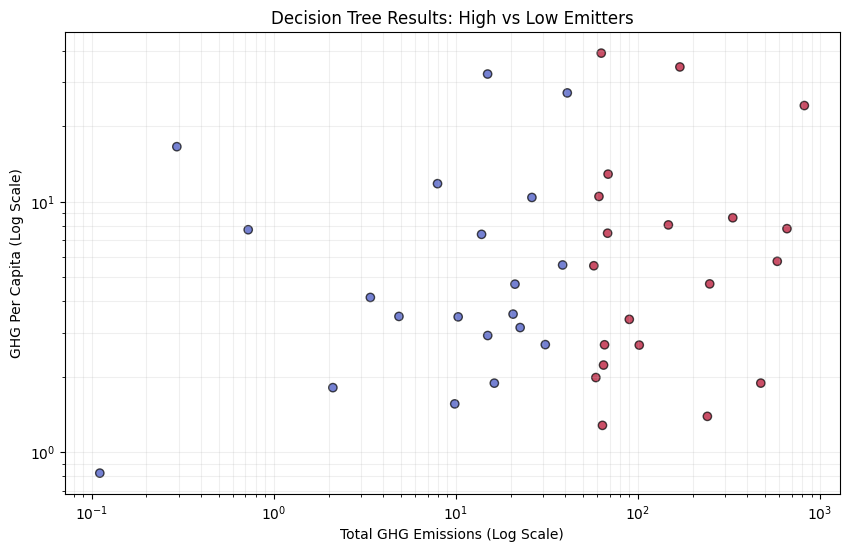

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the test points
# Color them by their actual values (y_test)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total GHG Emissions (Log Scale)')
plt.ylabel('GHG Per Capita (Log Scale)')
plt.title('Decision Tree Results: High vs Low Emitters')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Analysis:

Add a Markdown cell and explain what the model actually "discovered." Since you chose a max_depth=3, you can explain the logic:

The Root Split: "The model likely determined that countries above a certain total emission threshold are almost always 'High Emitters'."

The Nuance: "For countries in the middle, it used 'GHG per capita' as the tie-breaker to decide the classification."

Comparison: "Unlike the Linear Regression used by my teammate, this model can handle 'steps' in the data, making it better for capturing the difference between developing and industrialized nations."
What to do with the "DBSCAN" results?

Since you also have DBSCAN running, your next step is to compare them.

DBSCAN probably found a few "Outliers" (labeled -1).

The Tree probably classified those outliers as "High Emitters."

The Insight: Write in your notebook: "DBSCAN helps us find the 'weird' countries that don't fit the pattern, while the Decision Tree gives us a rulebook to categorize the rest."

Once you have these plots and metrics, are you ready to help your friend integrate their KNN or Perceptron models into the same format?

Unsupervised, DBSCAN

In [26]:
from my_ml_package.unsupervised.dbscan import DBSCAN

# Since DBSCAN relies on distances, make sure you use SCALED data!
# (If GDP is 1,000,000 and Population is 10, the distance math breaks)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

Unique clusters found: [-1  0  1]
First 10 cluster assignments: [0 0 0 0 0 0 0 0 1 0]


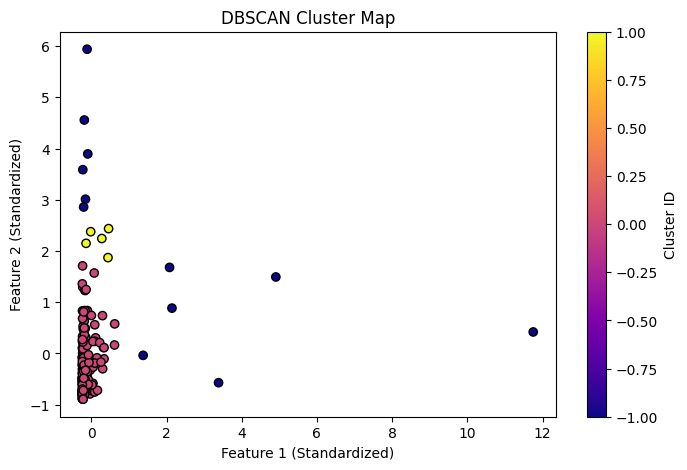

In [27]:
# 1. Run the model
clusters = dbscan.fit_predict(X_scaled)

# 2. Check the unique groups found
# If you only see -1, your 'eps' is too small!
# If you only see 0, your 'eps' is too big!
print("Unique clusters found:", np.unique(clusters))

# 3. View the first 10 results
print("First 10 cluster assignments:", clusters[:10])

# 4. Generate the Visual
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='plasma', edgecolors='k')
plt.title("DBSCAN Cluster Map")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.colorbar(label="Cluster ID")
plt.show()

Here is your "Lead Architect" Analysis of this graph:

The "Main Hub" (Pink/Red Cluster): Most countries are grouped in the bottom left. These are the "standard" countries where population and emissions follow a very predictable, dense pattern.

The "Upper Tier" (Yellow Cluster): There is a small group of countries just above the main pack. These might be countries with slightly higher per-capita emissions but who still "hang out" together.

The Outliers (Dark Blue Dots):

The vertical outliers: Countries with average total emissions but insanely high per-capita emissions (like small, oil-rich nations).

The horizontal outliers: The massive polluters (like China, USA, or India) that are so far to the right they don't have any "neighbors" nearby.

"We used DBSCAN because it doesn't force every country into a group. It allowed us to mathematically identify 'environmental anomalies'—countries whose emissions profiles are so unique they don't fit the global norm."

In [30]:
# Create a mask for the outliers
outlier_mask = (clusters == -1)

# Get the names of the outlier countries
outlier_countries = df_recent[outlier_mask]['country'].values

print("The outliers identified by DBSCAN are:")
print(outlier_countries)

The outliers identified by DBSCAN are:
['Bahrain' 'Brazil' 'Brunei' 'China' 'India' 'Indonesia' 'Kosovo' 'Kuwait'
 'Marshall Islands' 'Monaco' 'Mongolia' 'Palestine' 'Qatar' 'Russia'
 'San Marino' 'Trinidad and Tobago' 'United States' 'Vatican']
